In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam


from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.applications import VGG16
from sklearn.utils import class_weight

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

import os, cv2, json
from PIL import Image

In [2]:
WORK_DIR = '../input/cassava-leaf-disease-classification'
os.listdir(WORK_DIR)

['train_tfrecords',
 'sample_submission.csv',
 'test_tfrecords',
 'label_num_to_disease_map.json',
 'train_images',
 'train.csv',
 'test_images']

In [3]:
list_dir = os.listdir(os.path.join(WORK_DIR, "train_images"))
print(list_dir[0:5])
print(len(list_dir))
with open(os.path.join(WORK_DIR, "label_num_to_disease_map.json")) as file:
    print(json.dumps(json.loads(file.read()), indent=2))
    
train_labels = pd.read_csv(os.path.join(WORK_DIR, "train.csv"))
train_labels.head()

['1235188286.jpg', '1215607589.jpg', '478554372.jpg', '2763304605.jpg', '2826122413.jpg']
21397
{
  "0": "Cassava Bacterial Blight (CBB)",
  "1": "Cassava Brown Streak Disease (CBSD)",
  "2": "Cassava Green Mottle (CGM)",
  "3": "Cassava Mosaic Disease (CMD)",
  "4": "Healthy"
}


,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [4]:
print(train_labels)

             image_id  label
0      1000015157.jpg      0
1      1000201771.jpg      3
2       100042118.jpg      1
3      1000723321.jpg      1
4      1000812911.jpg      3
...               ...    ...
21392   999068805.jpg      3
21393   999329392.jpg      3
21394   999474432.jpg      1
21395   999616605.jpg      4
21396   999998473.jpg      4

[21397 rows x 2 columns]


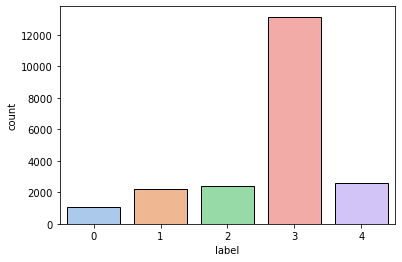

In [4]:
sns.countplot(train_labels.label, edgecolor = 'black',
              palette = sns.color_palette("pastel", 5))
plt.show()

In [5]:
sample = train_labels[train_labels.label == 3].sample(1)
print(train_labels[train_labels.label == 3])
image = cv2.imread(os.path.join(WORK_DIR, "train_images", sample.iloc[0,0]))


             image_id  label
1      1000201771.jpg      3
4      1000812911.jpg      3
5      1000837476.jpg      3
9      1001742395.jpg      3
10     1001749118.jpg      3
...               ...    ...
21386   997485103.jpg      3
21387   997651546.jpg      3
21388   997857988.jpg      3
21392   999068805.jpg      3
21393   999329392.jpg      3

[13158 rows x 2 columns]


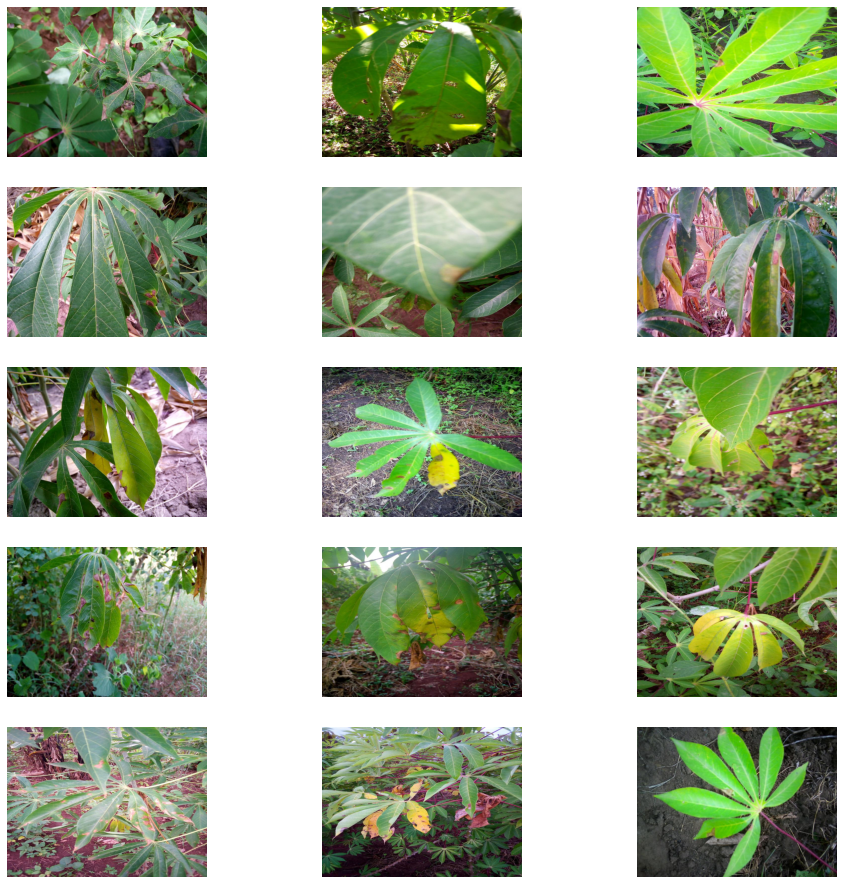

In [6]:
sample = train_labels[train_labels.label == 0].sample(15)
plt.figure(figsize=(16, 16))
for ind, (image_id, label) in enumerate(zip(sample.image_id, sample.label)):
    plt.subplot(5, 3, ind + 1)
    image = cv2.imread(os.path.join(WORK_DIR, "train_images", image_id))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.axis("off")
    
plt.show()

In [7]:
BATCH_SIZE = 16
STEPS_PER_EPOCH = len(train_labels)*0.8 / BATCH_SIZE
VALIDATION_STEPS = len(train_labels)*0.2 / BATCH_SIZE
EPOCHS = 10
TARGET_SIZE = 224

train_labels.label = train_labels.label.astype('str')
print(type(train_labels.label))


train_gen = ImageDataGenerator(validation_split = 0.2,
                                     preprocessing_function = None,
                                     zoom_range = 0.2,
                                     cval = 0.2,
                                     horizontal_flip = True,
                                     vertical_flip = True,
                                     fill_mode = 'nearest',
                                     shear_range = 0.2,
                                     height_shift_range = 0.2,
                                     width_shift_range = 0.2, 
                                     rescale=1.0/255.0) 

valid_gen = ImageDataGenerator(validation_split=0.2, rescale=1.0/255.0) 

train_it = train_gen.flow_from_dataframe(train_labels,
                         directory = os.path.join(WORK_DIR, "train_images"),
                         subset = "training",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "sparse")
print(train_it)

valid_it = valid_gen.flow_from_dataframe(train_labels,
                         directory = os.path.join(WORK_DIR, "train_images"),
                         subset = "validation",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "sparse")


<class 'pandas.core.series.Series'>
Found 17118 validated image filenames belonging to 5 classes.
Found 4279 validated image filenames belonging to 5 classes.


In [8]:
A=np.concatenate((train_it[0][0],train_it[1][0]),axis=0)
y_train=np.concatenate((train_it[0][1],train_it[1][1]),axis=0)
B=np.concatenate((valid_it[0][0],valid_it[1][0]),axis=0)
y_test=np.concatenate((valid_it[0][1],valid_it[1][1]),axis=0)
for i in range(298):
    A = np.concatenate((A, train_it[i+2][0]),axis=0)
    y_train = np.concatenate((y_train, train_it[i+2][1]),axis=0)
    print(A.shape)
    print(y_train.shape)
del train_it


(48, 224, 224, 3)
(48,)
(64, 224, 224, 3)
(64,)
(80, 224, 224, 3)
(80,)
(96, 224, 224, 3)
(96,)
(112, 224, 224, 3)
(112,)
(128, 224, 224, 3)
(128,)
(144, 224, 224, 3)
(144,)
(160, 224, 224, 3)
(160,)
(176, 224, 224, 3)
(176,)
(192, 224, 224, 3)
(192,)
(208, 224, 224, 3)
(208,)
(224, 224, 224, 3)
(224,)
(240, 224, 224, 3)
(240,)
(256, 224, 224, 3)
(256,)
(272, 224, 224, 3)
(272,)
(288, 224, 224, 3)
(288,)
(304, 224, 224, 3)
(304,)
(320, 224, 224, 3)
(320,)
(336, 224, 224, 3)
(336,)
(352, 224, 224, 3)
(352,)
(368, 224, 224, 3)
(368,)
(384, 224, 224, 3)
(384,)
(400, 224, 224, 3)
(400,)
(416, 224, 224, 3)
(416,)
(432, 224, 224, 3)
(432,)
(448, 224, 224, 3)
(448,)
(464, 224, 224, 3)
(464,)
(480, 224, 224, 3)
(480,)
(496, 224, 224, 3)
(496,)
(512, 224, 224, 3)
(512,)
(528, 224, 224, 3)
(528,)
(544, 224, 224, 3)
(544,)
(560, 224, 224, 3)
(560,)
(576, 224, 224, 3)
(576,)
(592, 224, 224, 3)
(592,)
(608, 224, 224, 3)
(608,)
(624, 224, 224, 3)
(624,)
(640, 224, 224, 3)
(640,)
(656, 224, 224, 3)
(

In [9]:
for i in range(98):
    B = np.concatenate((B, valid_it[i+2][0]),axis=0)
    y_test = np.concatenate((y_test, valid_it[i+2][1]),axis=0)
    print(B.shape)
    print(y_test.shape)
del valid_it

(48, 224, 224, 3)
(48,)
(64, 224, 224, 3)
(64,)
(80, 224, 224, 3)
(80,)
(96, 224, 224, 3)
(96,)
(112, 224, 224, 3)
(112,)
(128, 224, 224, 3)
(128,)
(144, 224, 224, 3)
(144,)
(160, 224, 224, 3)
(160,)
(176, 224, 224, 3)
(176,)
(192, 224, 224, 3)
(192,)
(208, 224, 224, 3)
(208,)
(224, 224, 224, 3)
(224,)
(240, 224, 224, 3)
(240,)
(256, 224, 224, 3)
(256,)
(272, 224, 224, 3)
(272,)
(288, 224, 224, 3)
(288,)
(304, 224, 224, 3)
(304,)
(320, 224, 224, 3)
(320,)
(336, 224, 224, 3)
(336,)
(352, 224, 224, 3)
(352,)
(368, 224, 224, 3)
(368,)
(384, 224, 224, 3)
(384,)
(400, 224, 224, 3)
(400,)
(416, 224, 224, 3)
(416,)
(432, 224, 224, 3)
(432,)
(448, 224, 224, 3)
(448,)
(464, 224, 224, 3)
(464,)
(480, 224, 224, 3)
(480,)
(496, 224, 224, 3)
(496,)
(512, 224, 224, 3)
(512,)
(528, 224, 224, 3)
(528,)
(544, 224, 224, 3)
(544,)
(560, 224, 224, 3)
(560,)
(576, 224, 224, 3)
(576,)
(592, 224, 224, 3)
(592,)
(608, 224, 224, 3)
(608,)
(624, 224, 224, 3)
(624,)
(640, 224, 224, 3)
(640,)
(656, 224, 224, 3)
(

In [10]:
y_train=y_train.astype(int)
y_test=y_test.astype(int)

#x_train=0.30*A[:,:,:,0] + 0.59*A[:,:,:,1]  + 0.11*A[:,:,:,2] 
x_train=A
del A
#x_test=0.30*B[:,:,:,0] + 0.59*B[:,:,:,1]  + 0.11*B[:,:,:,2] 
x_test=B
del B
#x_train=tf.reshape(x_train, shape=[1600,28,28,1])
#x_test=tf.reshape(x_test, shape=[1600,28,28,1])
print(x_train.shape)

(4800, 224, 224, 3)


In [11]:
from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow.keras.layers import Dense, Flatten, Conv2D, BatchNormalization
from tensorflow.keras import Model
import time

In [12]:
import sys
sys.path.append('tensorflow_v2_cvae_sample')

In [13]:
#from shutil import copyfile

# copy our file into the working directory (make sure it has .py suffix)
#copyfile(src = "../input/axilury2/cvae.py", dst = "../working/cvae.py")

#from cvae import CVAE, optimizer, log_normal_pdf, compute_loss, train_step


import numpy as np
import tensorflow as tf

class CVAE(tf.keras.Model):
    def __init__(self, latent_dim, label_size):
        super(CVAE, self).__init__()
        (self.latent_dim, self.label_size) = (latent_dim, label_size)
        self.encoder = tf.keras.Sequential(
           [
            tf.keras.layers.InputLayer(input_shape=(224, 224, label_size + 3)),
            tf.keras.layers.Conv2D(
                filters=32, kernel_size=3, strides=(2, 2), activation='relu'),
            tf.keras.layers.Conv2D(
                filters=24, kernel_size=3, strides=(2, 2), activation='relu'),
            tf.keras.layers.Conv2D(
                filters=20, kernel_size=3, strides=(2, 2), activation='relu'),
            tf.keras.layers.Conv2D(
                filters=16, kernel_size=3, strides=(2, 2), activation='relu'),
            tf.keras.layers.Conv2D(
                filters=12, kernel_size=3, strides=(2, 2), activation='relu'),
            tf.keras.layers.Flatten(),
            # No activation
            tf.keras.layers.Dense(latent_dim + latent_dim),
          ]
        )

        self.decoder = tf.keras.Sequential(
            [
            tf.keras.layers.InputLayer(input_shape=(latent_dim + label_size,)),
            tf.keras.layers.Dense(units=7*7*32, activation=tf.nn.relu),
            tf.keras.layers.Reshape(target_shape=(7, 7, 32)),
            tf.keras.layers.Conv2DTranspose(
                filters=12, kernel_size=3, strides=2, padding='same',
                activation='relu'),
            tf.keras.layers.Conv2DTranspose(
                filters=16, kernel_size=3, strides=2, padding='same',
                activation='relu'),
            tf.keras.layers.Conv2DTranspose(
                filters=20, kernel_size=3, strides=2, padding='same',
                activation='relu'),
            tf.keras.layers.Conv2DTranspose(
                filters=24, kernel_size=3, strides=2, padding='same',
                activation='relu'),
            tf.keras.layers.Conv2DTranspose(
                filters=32, kernel_size=3, strides=2, padding='same',
                activation='relu'),
            # No activation
            tf.keras.layers.Conv2DTranspose(
                filters=3, kernel_size=3, strides=1, padding='same'),
           ]
         )

    @tf.function
    def sample(self, eps=None, y=None):
        if eps is None:
            eps = tf.random.normal(shape=(100, self.latent_dim))
        return self.decode(eps, y, apply_sigmoid=True)

    def encode(self, x, y):
        n_sample = x.shape[0]
        image_size = x.shape[1:3]

        y_onehot = tf.reshape(tf.one_hot(y, self.label_size), [n_sample, 1, 1, self.label_size]) # 1 x 1 x label_size
        k = tf.ones([n_sample, *image_size, 1]) # {image_size} x 1
        h = tf.concat([x, k * y_onehot], 3) # {image_size} x (1 + label_size)

        mean, logvar = tf.split(self.encoder(h), num_or_size_splits=2, axis=1)
        return mean, logvar

    def reparameterize(self, mean, logvar):
        eps = tf.random.normal(shape=mean.shape)
        return eps * tf.exp(logvar * .5) + mean

    def decode(self, z, y=None, apply_sigmoid=False):
        n_sample = z.shape[0]
        if not y is None:
            y_onehot = tf.reshape(tf.one_hot(y, self.label_size), [n_sample, self.label_size]) # label_size
            h = tf.concat([z, y_onehot], 1) # latent_dim + label_size
        else:
            h = tf.concat([z, tf.zeros([n_sample, self.label_size])], 1)  # latent_dim + label_size
        logits = self.decoder(h)
        if apply_sigmoid:
            probs = tf.sigmoid(logits)
            return probs
        return logits


optimizer = tf.keras.optimizers.Adam(1e-4)


def log_normal_pdf(sample, mean, logvar, raxis=1):
    log2pi = tf.math.log(2. * np.pi)
    return tf.reduce_sum(-.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi),axis=raxis)


def compute_loss(model, xy):
    (x, y) = xy # x: image, y: label
    mean, logvar = model.encode(x, y)
    z = model.reparameterize(mean, logvar)
    x_logit = model.decode(z, y)
    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x)
    logpx_z = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])
    logpz = log_normal_pdf(z, 0., 0.)
    logqz_x = log_normal_pdf(z, mean, logvar)
    return -tf.reduce_mean(logpx_z + logpz - logqz_x)


@tf.function
def train_step(model, xy, optimizer):
    with tf.GradientTape() as tape:
        loss = compute_loss(model, xy)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))


    
    
    
    
    


In [14]:
def preprocess_images(images):
    images = images.reshape((images.shape[0],TARGET_SIZE , TARGET_SIZE, 3)) / 255.
    return np.where(images > .5, 1.0, 0.0).astype('float32')

#x_train = preprocess_images(x_train)

#x_test = preprocess_images(x_test)

train_size = x_train.shape[0] 
batch_size = 16
test_size = x_test.shape[0] 
label_size = 5

train_dataset_x = tf.data.Dataset.from_tensor_slices(x_train)
del x_train
test_dataset_x = tf.data.Dataset.from_tensor_slices(x_test)

print(train_dataset_x, test_dataset_x)

train_dataset_y= tf.data.Dataset.from_tensor_slices(y_train)

test_dataset_y = tf.data.Dataset.from_tensor_slices(y_test)

print(train_dataset_y, test_dataset_y)

train_dataset_xy = tf.data.Dataset.zip((train_dataset_x, train_dataset_y))
del train_dataset_x,train_dataset_y
train_dataset_xy = train_dataset_xy.shuffle(train_size).batch(batch_size)
test_dataset_xy = tf.data.Dataset.zip((test_dataset_x, test_dataset_y))
del test_dataset_x,test_dataset_y
test_dataset_xy = test_dataset_xy.shuffle(train_size).batch(batch_size)
print(train_dataset_xy, test_dataset_xy)

<TensorSliceDataset shapes: (224, 224, 3), types: tf.float32> <TensorSliceDataset shapes: (224, 224, 3), types: tf.float32>
<TensorSliceDataset shapes: (), types: tf.int64> <TensorSliceDataset shapes: (), types: tf.int64>
<BatchDataset shapes: ((None, 224, 224, 3), (None,)), types: (tf.float32, tf.int64)> <BatchDataset shapes: ((None, 224, 224, 3), (None,)), types: (tf.float32, tf.int64)>


In [15]:

# set the dimensionality of the latent space to a plane for visualization later
latent_dim = 64
num_examples_to_generate = 16

model = CVAE(latent_dim, label_size)
print(model.encoder.summary())
print('')
print(model.decoder.summary())


def generate_and_save_images(model, epoch, test_sample):
    mean, logvar = model.encode(*test_sample)
    z = model.reparameterize(mean, logvar)
    predictions = model.sample(z, test_sample[1])
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.figure()
        plt.imshow(predictions[i, :, :, :])
        plt.savefig('image_at_epoch_{:04d}_{n}th_member.png'.format(epoch,n=i))
        plt.axis('off')
    # tight_layout minimizes the overlap between 2 sub-plots
    plt.show()

assert batch_size >= num_examples_to_generate
for test_batch in test_dataset_xy.take(1):
    test_sample = (test_batch[0][0:num_examples_to_generate, :,  :, :], test_batch[1][0:num_examples_to_generate])

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 111, 111, 32)      2336      
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 55, 55, 24)        6936      
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 27, 27, 20)        4340      
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 13, 13, 16)        2896      
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 6, 6, 12)          1740      
_________________________________________________________________
flatten (Flatten)            (None, 432)               0         
_________________________________________________________________
dense (Dense)                (None, 128)               5

(<tf.Tensor: shape=(16, 224, 224, 3), dtype=float32, numpy=
array([[[[0.2392157 , 0.45098042, 0.22352943],
         [0.25882354, 0.48627454, 0.25882354],
         [0.22352943, 0.45882356, 0.25882354],
         ...,
         [0.24705884, 0.38431376, 0.2901961 ],
         [0.56078434, 0.7137255 , 0.6392157 ],
         [0.43921572, 0.6431373 , 0.5568628 ]],

        [[0.33333334, 0.54901963, 0.43529415],
         [0.2784314 , 0.50980395, 0.3921569 ],
         [0.29411766, 0.5372549 , 0.43921572],
         ...,
         [0.39607847, 0.54509807, 0.38431376],
         [0.40000004, 0.54901963, 0.35686275],
         [0.5882353 , 0.74509805, 0.50980395]],

        [[0.27058825, 0.49803925, 0.43921572],
         [0.19215688, 0.43137258, 0.36078432],
         [0.19215688, 0.4431373 , 0.3803922 ],
         ...,
         [0.5686275 , 0.7372549 , 0.5294118 ],
         [0.57254905, 0.7176471 , 0.454902  ],
         [0.6431373 , 0.77647066, 0.43921572]],

        ...,

        [[0.1764706 , 0.34117648

<Figure size 288x288 with 0 Axes>

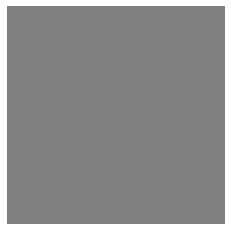

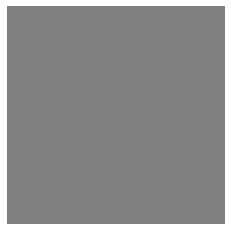

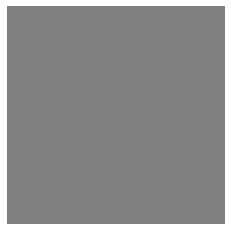

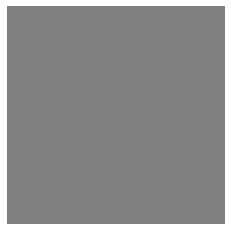

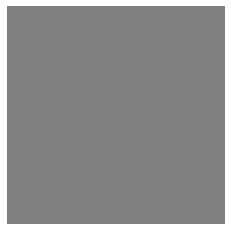

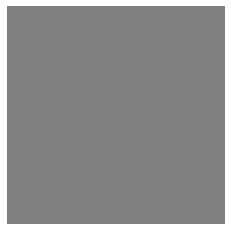

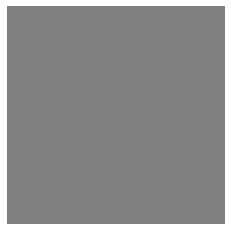

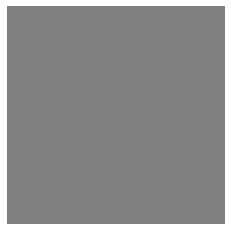

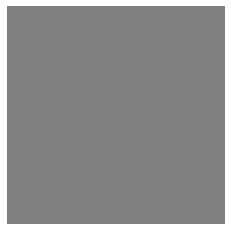

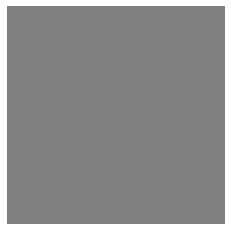

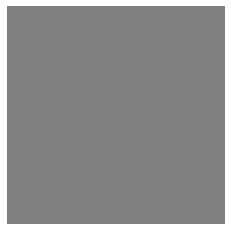

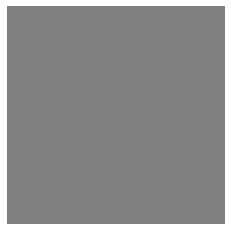

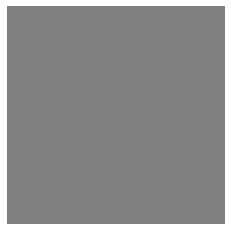

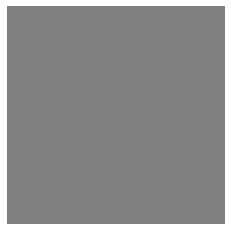

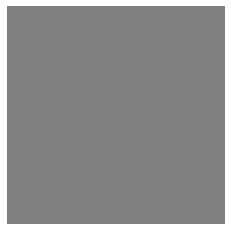

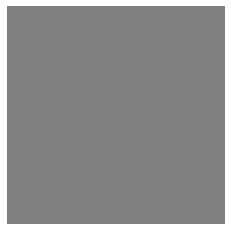

In [18]:
print(test_sample)
           
                 
generate_and_save_images(model, 0, test_sample)

In [16]:
epochs = 50

for epoch in range(1, epochs + 1):
    start_time = time.time()
    for train in train_dataset_xy:
        train_step(model, train, optimizer)
    end_time = time.time()
    loss_tr = tf.keras.metrics.Mean()
    for train in train_dataset_xy:
        loss_tr(compute_loss(model, train))
    elbo_tr = -loss_tr.result()
    loss_tst = tf.keras.metrics.Mean()
    for test in test_dataset_xy:
        loss_tst(compute_loss(model, test))
    elbo_tst = -loss_tst.result()
    #display.clear_output(wait=False)
    print(f'Epoch: {epoch}, Train set ELBO: {elbo_tr}, Test set ELBO: {elbo_tst}, time elapse for current epoch: {end_time - start_time}')
    #if epoch==30:
        #generate_and_save_images(model, epoch, test_sample)

Epoch: 1, Train set ELBO: -98897.015625, Test set ELBO: -99269.03125, time elapse for current epoch: 15.41299033164978
Epoch: 2, Train set ELBO: -96579.75, Test set ELBO: -97206.6484375, time elapse for current epoch: 9.936600685119629
Epoch: 3, Train set ELBO: -95299.8828125, Test set ELBO: -96009.203125, time elapse for current epoch: 10.2973792552948
Epoch: 4, Train set ELBO: -94827.390625, Test set ELBO: -95581.921875, time elapse for current epoch: 10.118284463882446
Epoch: 5, Train set ELBO: -94427.96875, Test set ELBO: -95202.0390625, time elapse for current epoch: 10.072702646255493
Epoch: 6, Train set ELBO: -94159.15625, Test set ELBO: -94952.03125, time elapse for current epoch: 10.08364224433899
Epoch: 7, Train set ELBO: -93964.5390625, Test set ELBO: -94772.15625, time elapse for current epoch: 10.08538031578064
Epoch: 8, Train set ELBO: -93798.2109375, Test set ELBO: -94615.78125, time elapse for current epoch: 9.881089925765991
Epoch: 9, Train set ELBO: -93667.265625, Tes

In [ ]:
for i in range(100):
    for test_batch in test_dataset_xy.take(i):
        test_sample = (test_batch[0][0:num_examples_to_generate, :,  :, :], test_batch[1][0:num_examples_to_generate])
        generate_and_save_images(model, i, test_sample)
    

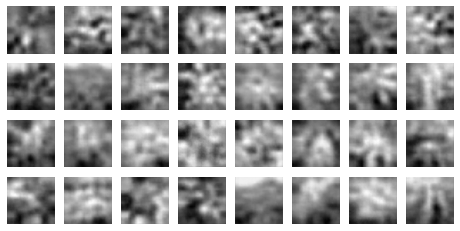

In [22]:
def show_pics(pics):
    fig = plt.figure(figsize=(8, 4))
    for i in range(pics.shape[0]):
        plt.subplot(4, 8, i + 1)
        plt.imshow(pics[i, :, :, 0], cmap='gray')
        plt.axis('off')
        
mean, logvar = model.encode(x_test[0:32], y_test[0:32])
z = model.reparameterize(mean, logvar)
show_pics(model.decode(z, y_test[0:32]))



In [45]:
def create_model():   
    # Good resource 
    # https://androidkt.com/how-to-use-vgg-model-in-tensorflow-keras/
    
    vgg16_model = VGG16(include_top=False, input_shape=(TARGET_SIZE, TARGET_SIZE, 3), weights='imagenet' )
                  
    vgg16_model.trainable=False                
    
    global_average_layer = tf.keras.layers.GlobalAveragePooling2D()              
                  
    prediction_layer = tf.keras.layers.Dense(5, activation='softmax')
    
    model = tf.keras.Sequential([vgg16_model,
                                 global_average_layer,
                                 prediction_layer
                                 ])
    
    
    
    opt = Adam(lr = 0.0001)
    
    # The following resource was very helpful to 
    # treat the imbalanced class problem. 
    # https://medium.com/@markryan_69718/what-to-do-when-the-labels-are-skewed-tackling-the-accuracy-paradox-7b72bd4a9ccc
        
    
    
    model.compile(optimizer = opt ,
                  loss = "sparse_categorical_crossentropy",
                  metrics = ["acc"], 
                  weighted_metrics=["accuracy"]
                 )
    return model

In [41]:
print(x_test.shape)

(1600, 224, 224, 3)


In [46]:
model_base = create_model()
model_base.summary()

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 7, 7, 512)         14714688  
_________________________________________________________________
global_average_pooling2d_2 ( (None, 512)               0         
_________________________________________________________________
dense_7 (Dense)              (None, 5)                 2565      
Total params: 14,717,253
Trainable params: 2,565
Non-trainable params: 14,714,688
_________________________________________________________________


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

optimizer = keras.optimizers.SGD(learning_rate=1e-3)
# Instantiate a loss function.
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Prepare the training dataset.
batch_size = 16

train_acc_metric = keras.metrics.SparseCategoricalAccuracy()

epochs = 10
for epoch in range(epochs):
    print("\nStart of epoch %d" % (epoch,))

    # Iterate over the batches of the dataset.
    for i in range(100):
        mean, logvar = model.encode(x_test[16*i:16*(i+1)], y_test[16*i:16*(i+1)])
        z = model.reparameterize(mean, logvar)
        x_batch_train=model.decode(z, y_test[16*i:16*(i+1)])
        y_batch_train=y_test[16*i:16*(i+1)]

        # Open a GradientTape to record the operations run
        # during the forward pass, which enables auto-differentiation.
        with tf.GradientTape() as tape:

            # Run the forward pass of the layer.
            # The operations that the layer applies
            # to its inputs are going to be recorded
            # on the GradientTape.
            logits = model_base(x_batch_train, training=True)  # Logits for this minibatch

            # Compute the loss value for this minibatch.
            loss_value = loss_fn(y_batch_train, logits)

        # Use the gradient tape to automatically retrieve
        # the gradients of the trainable variables with respect to the loss.
        grads = tape.gradient(loss_value, model_base.trainable_weights)
        train_acc_metric.update_state(y_batch_train, logits)
        # Run one step of gradient descent by updating
        # the value of the variables to minimize the loss.
        optimizer.apply_gradients(zip(grads, model_base.trainable_weights))
        

        # Log every 200 batches.
        if i % 99 == 0:
            print(
                "Training loss (for one batch) at step %d: %.4f"
                % (i, float(loss_value))
            )
            print("Seen so far: %s samples" % ((i + 1) * 16))
    train_acc = train_acc_metric.result()
    print("Training acc over epoch: %.4f" % (float(train_acc),))

    # Reset training metrics at the end of each epoch
    train_acc_metric.reset_states()


Start of epoch 0
Training loss (for one batch) at step 0: 2.1450
Seen so far: 16 samples
Training loss (for one batch) at step 99: 1.2776
Seen so far: 1600 samples
Training acc over epoch: 0.5319

Start of epoch 1
Training loss (for one batch) at step 0: 1.1793
Seen so far: 16 samples
Training loss (for one batch) at step 99: 1.2611
Seen so far: 1600 samples
Training acc over epoch: 0.6156

Start of epoch 2
Training loss (for one batch) at step 0: 1.1596
Seen so far: 16 samples


In [ ]:
model_base = create_model()
model_base.summary()

In [31]:
epochs = 50
for epoch in range(epochs):
    print("\nStart of epoch %d" % (epoch,))

    # Iterate over the batches of the dataset.
    for i in range(100):
        x_batch_train=x_test[16*i:16*(i+1)]
        y_batch_train=y_test[16*i:16*(i+1)]

        # Open a GradientTape to record the operations run
        # during the forward pass, which enables auto-differentiation.
        with tf.GradientTape() as tape:

            # Run the forward pass of the layer.
            # The operations that the layer applies
            # to its inputs are going to be recorded
            # on the GradientTape.
            logits = model_base(x_batch_train, training=True)  # Logits for this minibatch

            # Compute the loss value for this minibatch.
            loss_value = loss_fn(y_batch_train, logits)

        # Use the gradient tape to automatically retrieve
        # the gradients of the trainable variables with respect to the loss.
        grads = tape.gradient(loss_value, model_base.trainable_weights)
        train_acc_metric.update_state(y_batch_train, logits)

        # Run one step of gradient descent by updating
        # the value of the variables to minimize the loss.
        optimizer.apply_gradients(zip(grads, model_base.trainable_weights))
        

        # Log every 200 batches.
        if i % 99 == 0:
            print(
                "Training loss (for one batch) at step %d: %.4f"
                % (i, float(loss_value))
            )
            print("Seen so far: %s samples" % ((i + 1) * 16))
    train_acc = train_acc_metric.result()
    print("Training acc over epoch: %.4f" % (float(train_acc),))

    # Reset training metrics at the end of each epoch
    train_acc_metric.reset_states()


Start of epoch 0
Training loss (for one batch) at step 0: 1.0203
Seen so far: 16 samples
Training loss (for one batch) at step 99: 1.0544
Seen so far: 1600 samples
Training acc over epoch: 0.6219

Start of epoch 1
Training loss (for one batch) at step 0: 0.9570
Seen so far: 16 samples
Training loss (for one batch) at step 99: 1.0498
Seen so far: 1600 samples
Training acc over epoch: 0.6231

Start of epoch 2
Training loss (for one batch) at step 0: 0.9524
Seen so far: 16 samples
Training loss (for one batch) at step 99: 1.0461
Seen so far: 1600 samples
Training acc over epoch: 0.6231

Start of epoch 3
Training loss (for one batch) at step 0: 0.9491
Seen so far: 16 samples
Training loss (for one batch) at step 99: 1.0425
Seen so far: 1600 samples
Training acc over epoch: 0.6250

Start of epoch 4
Training loss (for one batch) at step 0: 0.9460
Seen so far: 16 samples
Training loss (for one batch) at step 99: 1.0391
Seen so far: 1600 samples
Training acc over epoch: 0.6250

Start of epoch

Training loss (for one batch) at step 99: 0.9536
Seen so far: 1600 samples
Training acc over epoch: 0.6406

Start of epoch 42
Training loss (for one batch) at step 0: 0.8716
Seen so far: 16 samples
Training loss (for one batch) at step 99: 0.9520
Seen so far: 1600 samples
Training acc over epoch: 0.6413

Start of epoch 43
Training loss (for one batch) at step 0: 0.8703
Seen so far: 16 samples
Training loss (for one batch) at step 99: 0.9504
Seen so far: 1600 samples
Training acc over epoch: 0.6413

Start of epoch 44
Training loss (for one batch) at step 0: 0.8691
Seen so far: 16 samples
Training loss (for one batch) at step 99: 0.9489
Seen so far: 1600 samples
Training acc over epoch: 0.6413

Start of epoch 45
Training loss (for one batch) at step 0: 0.8678
Seen so far: 16 samples
Training loss (for one batch) at step 99: 0.9474
Seen so far: 1600 samples
Training acc over epoch: 0.6406

Start of epoch 46
Training loss (for one batch) at step 0: 0.8666
Seen so far: 16 samples
Training l